

# **Comment analyser les données issues du CRM commercial pour maximiser les revenus et améliorer la performance globale des ventes ?**

# Chargement des données et des librairies

In [ ]:
# Importation des librairies utiles à l'analyse

import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib

In [ ]:
# Création des dataframes grâce aux fichiers csv

df_accounts = pd.read_csv('/content/accounts.csv')
df_sales_teams = pd.read_csv('/content/sales_teams.csv')
df_data_dictionary = pd.read_csv('/content/data_dictionary.csv')
df_products= pd.read_csv('/content/products.csv')
df_sales_pipeline= pd.read_csv('/content/sales_pipeline.csv')

#Exploration générale des données (pré projet)

In [ ]:
# Nom des colonnes du dataframe "products"

df_products.columns

Index(['product', 'series', 'sales_price'], dtype='object')

In [ ]:
# Définition des gammes existantes des différents produits

df_products['series'].value_counts()

,count
series,
GTX,4
MG,2
GTK,1


In [ ]:
# Informations du dataframe sales_pipeline

df_sales_pipeline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   opportunity_id  8800 non-null   object 
 1   sales_agent     8800 non-null   object 
 2   product         8800 non-null   object 
 3   account         7375 non-null   object 
 4   deal_stage      8800 non-null   object 
 5   engage_date     8300 non-null   object 
 6   close_date      6711 non-null   object 
 7   close_value     6711 non-null   float64
dtypes: float64(1), object(7)
memory usage: 550.1+ KB


In [ ]:
# Echantillon de 5 lignes aléatoires de la table sales_pipeline

df_sales_pipeline.sample(5)

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
6369,FYNL84HO,James Ascencio,GTX Plus Pro,Doncon,Won,2017-09-01,2017-11-13,6101.0
6269,EXXFSC3O,Cassey Cress,GTXPro,Opentech,Won,2017-08-29,2017-11-15,4343.0
6493,T3W0Z8KP,Versie Hillebrand,MG Special,Cancity,Won,2017-09-06,2017-09-12,61.0
3990,1V3IQVOF,Gladys Colclough,GTX Plus Basic,Ron-tech,Lost,2017-06-18,2017-08-02,0.0
1201,4MC584U5,Gladys Colclough,MG Advanced,Treequote,Won,2017-03-01,2017-06-02,4082.0


In [ ]:
# Observation des différents deal_stage des commandes

df_sales_pipeline['deal_stage'].value_counts()

,count
deal_stage,
Won,4238
Lost,2473
Engaging,1589
Prospecting,500


In [ ]:
# Liste de tous les clients et le nombre de commande qu'ils ont réalisées

df_sales_pipeline['account'].value_counts()

,count
account,
Hottechi,200
Kan-code,196
Konex,178
Condax,170
Dontechi,129
...,...
Newex,55
Bioplex,53
The New York Inquirer,52


In [ ]:
# Vérification des doublons des ID de vente

df_sales_pipeline['opportunity_id'].nunique()

8800

In [ ]:
# La nombre de lignes correspond bien

df_sales_pipeline['opportunity_id'].shape

(8800,)

In [ ]:
# Premier apercu des deal_stage "Lost" de la table sales_pipeline

df_sales_pipeline[df_sales_pipeline['deal_stage']=="Lost"]

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
11,KWVA7VR1,Gladys Colclough,GTXPro,Genco Pura Olive Oil Company,Lost,2016-11-04,2017-03-18,0.0
15,3F5MZNEH,Rosalina Dieter,MG Special,Sonron,Lost,2016-11-05,2017-03-03,0.0
18,902REDPA,Daniell Hammack,GTXPro,Xx-zobam,Lost,2016-11-07,2017-03-09,0.0
20,JJXRR8R6,James Ascencio,GTX Plus Pro,Fasehatice,Lost,2016-11-07,2017-03-17,0.0
27,AO9Z2D17,Violet Mclelland,GTX Plus Pro,Xx-zobam,Lost,2016-11-10,2017-03-11,0.0
...,...,...,...,...,...,...,...,...
8263,8LFA54EQ,Rosalina Dieter,MG Special,Newex,Lost,2017-12-16,2017-12-21,0.0
8270,Q30OVFCZ,Vicki Laflamme,GTX Plus Basic,Sonron,Lost,2017-12-17,2017-12-31,0.0
8278,OHAARANW,Darcel Schlecht,GTXPro,Bioholding,Lost,2017-12-19,2017-12-30,0.0
8282,CNL7PCYU,Donn Cantrell,MG Advanced,Xx-zobam,Lost,2017-12-20,2017-12-28,0.0


In [ ]:
# Premier apercu des deal_stage "Won" de la table sales_pipeline

df_sales_pipeline[df_sales_pipeline['deal_stage']=="Won"]

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0
...,...,...,...,...,...,...,...,...
8295,2EBLR9N8,Lajuana Vencill,GTX Basic,Conecom,Won,2017-12-24,2017-12-26,622.0
8296,VDGA4KXA,Violet Mclelland,GTX Plus Basic,Bluth Company,Won,2017-12-24,2017-12-30,1093.0
8297,6WCNNK5J,Maureen Marcano,GTXPro,Hottechi,Won,2017-12-26,2017-12-29,4433.0
8298,YJTQSZ9D,Gladys Colclough,GTX Plus Basic,Inity,Won,2017-12-27,2017-12-30,1052.0


In [ ]:
# Premier aperçu du dataframe "accounts" qui represente tous les clients et leurs infos

df_accounts

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,NaN
1,Betasoloin,medical,1999,251.41,495,United States,NaN
2,Betatech,medical,1986,647.18,1185,Kenya,NaN
3,Bioholding,medical,2012,587.34,1356,Philipines,NaN
4,Bioplex,medical,1991,326.82,1016,United States,NaN
...,...,...,...,...,...,...,...
80,Zathunicon,retail,2010,71.12,144,United States,NaN
81,Zencorporation,technolgy,2011,40.79,142,China,NaN
82,Zoomit,entertainment,1992,324.19,978,United States,NaN
83,Zotware,software,1979,4478.47,13809,United States,NaN


In [ ]:
# Lexique de la table "accounts" via le dataframe "data_dictionnary"

df_data_dictionary[df_data_dictionary['Table']=='accounts']

,Table,Field,Description
0,accounts,account,Company name
1,accounts,sector,Industry
2,accounts,year_established,Year Established
3,accounts,revenue,Annual revenue (in millions of USD)
4,accounts,employees,Number of employees
5,accounts,office_location,Headquarters
6,accounts,subsidiary_of,Parent company


In [ ]:
# Lexique de la table "sales_pipeline" via le dataframe "data_dictionnary"

df_data_dictionary[df_data_dictionary['Table']=='sales_pipeline']

,Table,Field,Description
13,sales_pipeline,opportunity_id,Unique identifier
14,sales_pipeline,sales_agent,Sales agent
15,sales_pipeline,product,Product name
16,sales_pipeline,account,Company name
17,sales_pipeline,deal_stage,Sales pipeline stage (Prospecting > Engaging >...
18,sales_pipeline,engage_date,"Date in which the ""Engaging"" deal stage was in..."
19,sales_pipeline,close_date,"Date in which the deal was ""Won"" or ""Lost"""
20,sales_pipeline,close_value,Revenue from the deal


In [ ]:
# Dénomination des produits commercialisés

df_products.value_counts()

,,,count
product,series,sales_price,
GTK 500,GTK,26768,1
GTX Basic,GTX,550,1
GTX Plus Basic,GTX,1096,1
GTX Plus Pro,GTX,5482,1
GTX Pro,GTX,4821,1
MG Advanced,MG,3393,1
MG Special,MG,55,1


# Nettoyage des données

##Table sales_pipeline :

In [ ]:
# Echantillon de 10 lignes de la table principale 'sales_pipeline'

df_sales_pipeline.sample(10)

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
6152,HF1GSBT4,Daniell Hammack,GTX Plus Pro,NaN,Engaging,2017-08-24,NaN,NaN
8257,USJ0JACE,Violet Mclelland,GTX Plus Basic,Massive Dynamic,Won,2017-12-14,2017-12-16,960.0
805,VC94R5H8,Vicki Laflamme,GTX Basic,Konex,Won,2017-02-09,2017-03-23,587.0
8456,8IPMP8NT,Darcel Schlecht,GTXPro,NaN,Prospecting,NaN,NaN,NaN
3388,IDBXD4OU,Kary Hendrixson,GTX Basic,Scotfind,Lost,2017-05-24,2017-08-22,0.0
5067,DL3Q5HAD,Rosie Papadopoulos,GTX Plus Pro,Umbrella Corporation,Won,2017-07-21,2017-08-23,4930.0
1195,RK5Y67V6,Darcel Schlecht,MG Special,Stanredtax,Won,2017-03-01,2017-03-08,60.0
5222,7R0TEEHW,Lajuana Vencill,MG Special,Condax,Lost,2017-07-24,2017-08-28,0.0
3958,PFKDTEYU,Rosie Papadopoulos,GTXPro,Xx-zobam,Engaging,2017-06-16,NaN,NaN
1953,XCBKZWDX,Kami Bicknell,MG Special,Plusstrip,Lost,2017-03-31,2017-06-20,0.0


In [ ]:
# Informations générales sur sales_pipeline :
# les colonnes de dates sont au format object, conversion au format date

df_sales_pipeline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   opportunity_id  8800 non-null   object 
 1   sales_agent     8800 non-null   object 
 2   product         8800 non-null   object 
 3   account         7375 non-null   object 
 4   deal_stage      8800 non-null   object 
 5   engage_date     8300 non-null   object 
 6   close_date      6711 non-null   object 
 7   close_value     6711 non-null   float64
dtypes: float64(1), object(7)
memory usage: 550.1+ KB


Conversion au bon format :

In [ ]:
# Utilisation de la méthode pd.to_datetime

df_sales_pipeline['close_date']= pd.to_datetime(df_sales_pipeline['close_date'])
df_sales_pipeline['engage_date']= pd.to_datetime(df_sales_pipeline['engage_date'])

In [ ]:
# Vérification des manipulations

df_sales_pipeline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   opportunity_id  8800 non-null   object        
 1   sales_agent     8800 non-null   object        
 2   product         8800 non-null   object        
 3   account         7375 non-null   object        
 4   deal_stage      8800 non-null   object        
 5   engage_date     8300 non-null   datetime64[ns]
 6   close_date      6711 non-null   datetime64[ns]
 7   close_value     6711 non-null   float64       
dtypes: datetime64[ns](2), float64(1), object(5)
memory usage: 550.1+ KB


In [ ]:
# Dates minimale et maximale de début des ventes

max(df_sales_pipeline['engage_date']), min(df_sales_pipeline['engage_date'])

(Timestamp('2017-12-27 00:00:00'), Timestamp('2016-10-20 00:00:00'))

Gestion des duplicates

In [ ]:
# Aucun doublon dans la table sales_pipepline

df_sales_pipeline.duplicated().sum()

np.int64(0)

Traitement des NaN



In [ ]:
# Identification des valeurs manquantes (NaN) dans la table sales_pipeline

df_sales_pipeline.isna().sum()

,0
opportunity_id,0
sales_agent,0
product,0
account,1425
deal_stage,0
engage_date,500
close_date,2089
close_value,2089


In [ ]:
# Étude des valeurs manquantes (NaN) dans la colonne "account", représentant les clients

df_sales_pipeline[df_sales_pipeline['account'].isna()]

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
9,HAXMC4IX,James Ascencio,MG Advanced,NaN,Engaging,2016-11-03,NaT,NaN
42,EG7OFLFR,Kami Bicknell,GTX Basic,NaN,Engaging,2016-11-14,NaT,NaN
44,OLVI7L8M,Cassey Cress,GTXPro,NaN,Engaging,2016-11-16,NaT,NaN
56,F5U1ACDD,Kami Bicknell,GTX Plus Basic,NaN,Engaging,2016-11-19,NaT,NaN
60,ZZY4516R,Hayden Neloms,MG Advanced,NaN,Engaging,2016-11-20,NaT,NaN
...,...,...,...,...,...,...,...,...
8795,9MIWFW5J,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN
8796,6SLKZ8FI,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN
8797,LIB4KUZJ,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN
8798,18IUIUK0,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN


In [ ]:
# Une grande partie des NaN est présente dans les lignes où la colonne "account" est vide

df_sales_pipeline[df_sales_pipeline['account'].isna()].isna().sum()

,0
opportunity_id,0
sales_agent,0
product,0
account,1425
deal_stage,0
engage_date,337
close_date,1425
close_value,1425


Lorsque la colonne account est à NaN dans la table sales_pipeline, je n’observe ni statut, ni close_date, ni close_value. J’en déduis que ces lignes n’auront pas d’impact sur l’analyse et décide donc de les supprimer.

In [ ]:
# Supression des NaN de la colonne "account"

df_sales_pipeline = df_sales_pipeline.dropna(subset=['account'])
df_sales_pipeline

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0
...,...,...,...,...,...,...,...,...
8761,VW8CEV4C,Versie Hillebrand,MG Special,Konmatfix,Prospecting,NaT,NaT,NaN
8762,KLUS7RVS,Versie Hillebrand,MG Special,Opentech,Prospecting,NaT,NaT,NaN
8763,ROM4I2T0,Versie Hillebrand,MG Special,Rundofase,Prospecting,NaT,NaT,NaN
8790,FCNN6UY0,Versie Hillebrand,MG Advanced,Ganjaflex,Prospecting,NaT,NaT,NaN


In [ ]:
# Tous les clients sont maintenant connus, poursuite de l’analyse des NaN

df_sales_pipeline.isna().sum()

,0
opportunity_id,0
sales_agent,0
product,0
account,0
deal_stage,0
engage_date,163
close_date,664
close_value,664


In [ ]:
# Toutes les valeurs manquantes de la colonne "engage_date" sont également manquantes dans les colonnes "close_date" et "close_value.

df_sales_pipeline[df_sales_pipeline['engage_date'].isna()].isna().sum()

,0
opportunity_id,0
sales_agent,0
product,0
account,0
deal_stage,0
engage_date,163
close_date,163
close_value,163


In [ ]:
# Je me rends compte que 163 valeurs manquantes sont dues au statut de la vente, à savoir "Prospecting". À ce stade, je ne dispose ni de date de début ni de date de fin du deal, ni de "close_value", car les clients sont encore en phase de démarchage.

df_sales_pipeline[df_sales_pipeline['deal_stage']=='Prospecting']

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
8300,6CWZFOHJ,Anna Snelling,GTX Basic,Green-Plus,Prospecting,NaT,NaT,NaN
8307,Q9UWOC28,Anna Snelling,GTX Plus Basic,Plusstrip,Prospecting,NaT,NaT,NaN
8308,YL29KX3L,Anna Snelling,GTX Plus Basic,Zumgoity,Prospecting,NaT,NaT,NaN
8311,9PDR4X2R,Anna Snelling,GTX Plus Pro,Hatfan,Prospecting,NaT,NaT,NaN
8312,9P9ISECL,Anna Snelling,GTX Plus Pro,Sumace,Prospecting,NaT,NaT,NaN
...,...,...,...,...,...,...,...,...
8761,VW8CEV4C,Versie Hillebrand,MG Special,Konmatfix,Prospecting,NaT,NaT,NaN
8762,KLUS7RVS,Versie Hillebrand,MG Special,Opentech,Prospecting,NaT,NaT,NaN
8763,ROM4I2T0,Versie Hillebrand,MG Special,Rundofase,Prospecting,NaT,NaT,NaN
8790,FCNN6UY0,Versie Hillebrand,MG Advanced,Ganjaflex,Prospecting,NaT,NaT,NaN


In [ ]:
# Pour le reste des valeurs manquantes, je constate qu’elles sont dues au statut "Engaging". Dans ce cas, la date de début est renseignée, mais ni la date de fin ni la "close_value" ne sont encore disponibles, la vente étant toujours en cours.

df_sales_pipeline[df_sales_pipeline['deal_stage']=='Engaging']

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
25,UP409DSB,Maureen Marcano,MG Advanced,Ganjaflex,Engaging,2016-11-10,NaT,NaN
64,0DRC1U9Q,Maureen Marcano,GTX Basic,Green-Plus,Engaging,2016-11-20,NaT,NaN
79,M7I5O9YU,Corliss Cosme,GTX Basic,Cheers,Engaging,2016-11-23,NaT,NaN
85,VDIU10RV,Markita Hansen,MG Special,Lexiqvolax,Engaging,2016-11-23,NaT,NaN
89,579LZ3F9,Daniell Hammack,GTX Plus Basic,J-Texon,Engaging,2016-11-24,NaT,NaN
...,...,...,...,...,...,...,...,...
8249,K9KGXL2E,Markita Hansen,MG Advanced,Lexiqvolax,Engaging,2017-12-13,NaT,NaN
8259,TOJ902PF,Daniell Hammack,GTX Plus Basic,Bioholding,Engaging,2017-12-15,NaT,NaN
8262,J5BCAQ1Z,Zane Levy,GTX Basic,Bioplex,Engaging,2017-12-15,NaT,NaN
8267,RTWE19SU,Kary Hendrixson,GTXPro,Conecom,Engaging,2017-12-17,NaT,NaN


Je conserve le reste des valeurs manquantes, car elles correspondent à des deals aux statuts "Prospecting" (aucun premier contact client n’a encore eu lieu) et "Engaging" (la date d’engagement est renseignée, mais la close_date et la close_value ne sont pas encore disponibles).

Je scinde le DataFrame en deux :


*   df1, qui regroupe les opportunités aux statuts "won" et "lost"
*   df2, qui regroupe les opportunités aux statuts "prospecting" et "engaging"

In [ ]:
# Création d’un df1 comprenant uniquement les deals finalisés, qu’ils soient réussis ("Won") ou non ("Lost")

df1 = df_sales_pipeline[df_sales_pipeline['deal_stage'].isin(['Won', 'Lost'])]
df1

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0
...,...,...,...,...,...,...,...,...
8295,2EBLR9N8,Lajuana Vencill,GTX Basic,Conecom,Won,2017-12-24,2017-12-26,622.0
8296,VDGA4KXA,Violet Mclelland,GTX Plus Basic,Bluth Company,Won,2017-12-24,2017-12-30,1093.0
8297,6WCNNK5J,Maureen Marcano,GTXPro,Hottechi,Won,2017-12-26,2017-12-29,4433.0
8298,YJTQSZ9D,Gladys Colclough,GTX Plus Basic,Inity,Won,2017-12-27,2017-12-30,1052.0


In [ ]:
# Création d’un df2 regroupant les ventes non conclues, à savoir les statuts "Engaging" et "Prospecting"
df2 = df_sales_pipeline[df_sales_pipeline['deal_stage'].isin(['Engaging', 'Prospecting'])]
df2

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
25,UP409DSB,Maureen Marcano,MG Advanced,Ganjaflex,Engaging,2016-11-10,NaT,NaN
64,0DRC1U9Q,Maureen Marcano,GTX Basic,Green-Plus,Engaging,2016-11-20,NaT,NaN
79,M7I5O9YU,Corliss Cosme,GTX Basic,Cheers,Engaging,2016-11-23,NaT,NaN
85,VDIU10RV,Markita Hansen,MG Special,Lexiqvolax,Engaging,2016-11-23,NaT,NaN
89,579LZ3F9,Daniell Hammack,GTX Plus Basic,J-Texon,Engaging,2016-11-24,NaT,NaN
...,...,...,...,...,...,...,...,...
8761,VW8CEV4C,Versie Hillebrand,MG Special,Konmatfix,Prospecting,NaT,NaT,NaN
8762,KLUS7RVS,Versie Hillebrand,MG Special,Opentech,Prospecting,NaT,NaT,NaN
8763,ROM4I2T0,Versie Hillebrand,MG Special,Rundofase,Prospecting,NaT,NaT,NaN
8790,FCNN6UY0,Versie Hillebrand,MG Advanced,Ganjaflex,Prospecting,NaT,NaT,NaN


In [ ]:
# Je retrouve bien les valeurs manquantes (NaN) dans ce DataFrame

df2.isna().sum()

,0
opportunity_id,0
sales_agent,0
product,0
account,0
deal_stage,0
engage_date,163
close_date,664
close_value,664


In [ ]:
# Séparation de df2 selon le deal_stage (Engaging / Prospecting)

df2_engaging = df_sales_pipeline[df_sales_pipeline['deal_stage'].isin(['Engaging'])]
df2_prospecting = df_sales_pipeline[df_sales_pipeline['deal_stage'].isin(['Prospecting'])]

In [ ]:
# Vérification des NaN

df2_engaging.isna().sum()

,0
opportunity_id,0
sales_agent,0
product,0
account,0
deal_stage,0
engage_date,0
close_date,501
close_value,501


In [ ]:
# Suppression des colonnes "close_date" et "close_value" dans df2_engaging, celles-ci ne contenant que des valeurs manquantes (NaN)

df2_engaging = df2_engaging.drop(columns=['close_date', 'close_value'])


In [ ]:
# Vérification

df2_prospecting.isna().sum()

,0
opportunity_id,0
sales_agent,0
product,0
account,0
deal_stage,0
engage_date,163
close_date,163
close_value,163


In [ ]:
# Suppression des colonnes "engage_date", "close_date" et "close_value" dans df2_prospecting

df2_prospecting = df2_prospecting.drop(columns=['engage_date','close_date', 'close_value'])

In [ ]:
# # Vérification que df1 ne contient que des deal_stage "Won" et "Lost"

df1['deal_stage'].value_counts()

,count
deal_stage,
Won,4238
Lost,2473


In [ ]:
# Verification que df2 ne contient que des deal_stage "Engaging" & "Prospecting"

df2['deal_stage'].value_counts()

,count
deal_stage,
Engaging,501
Prospecting,163


In [ ]:
# En excluant les deal_stages "Engaging" et "Prospecting", je n’observe plus de valeurs manquantes (NaN)

df1[df1['engage_date'].isna()].isna().sum()

,0
opportunity_id,0
sales_agent,0
product,0
account,0
deal_stage,0
engage_date,0
close_date,0
close_value,0


In [ ]:
# df1 ne contenant que des deals finalisés sans valeurs manquantes, je le scinde en deux sous-ensembles afin d’analyser séparément les ventes réussies ("Won") et non réussies ("Lost")

df1_won=df1[df1['deal_stage']=='Won']
df1_won

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0
...,...,...,...,...,...,...,...,...
8295,2EBLR9N8,Lajuana Vencill,GTX Basic,Conecom,Won,2017-12-24,2017-12-26,622.0
8296,VDGA4KXA,Violet Mclelland,GTX Plus Basic,Bluth Company,Won,2017-12-24,2017-12-30,1093.0
8297,6WCNNK5J,Maureen Marcano,GTXPro,Hottechi,Won,2017-12-26,2017-12-29,4433.0
8298,YJTQSZ9D,Gladys Colclough,GTX Plus Basic,Inity,Won,2017-12-27,2017-12-30,1052.0


In [ ]:
# Statistiques descriptives – ventes réussies

df1_won.describe()

,engage_date,close_date,close_value
count,4238,4238,4238.000000
mean,2017-06-09 12:50:58.046248192,2017-07-31 07:37:00.481359360,2360.909391
min,2016-10-20 00:00:00,2017-03-01 00:00:00,38.000000
25%,2017-03-25 00:00:00,2017-05-18 00:00:00,518.000000
50%,2017-06-12 00:00:00,2017-08-02 00:00:00,1117.000000
75%,2017-09-01 00:00:00,2017-10-16 00:00:00,4429.500000
max,2017-12-27 00:00:00,2017-12-31 00:00:00,30288.000000
std,NaN,NaN,2544.484463


In [ ]:
# Je crée un deuxième DataFrame à partir de df1, contenant uniquement les ventes abouties non réussies

df1_lost = df1[df1['deal_stage']=='Lost']
df1_lost

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
11,KWVA7VR1,Gladys Colclough,GTXPro,Genco Pura Olive Oil Company,Lost,2016-11-04,2017-03-18,0.0
15,3F5MZNEH,Rosalina Dieter,MG Special,Sonron,Lost,2016-11-05,2017-03-03,0.0
18,902REDPA,Daniell Hammack,GTXPro,Xx-zobam,Lost,2016-11-07,2017-03-09,0.0
20,JJXRR8R6,James Ascencio,GTX Plus Pro,Fasehatice,Lost,2016-11-07,2017-03-17,0.0
27,AO9Z2D17,Violet Mclelland,GTX Plus Pro,Xx-zobam,Lost,2016-11-10,2017-03-11,0.0
...,...,...,...,...,...,...,...,...
8263,8LFA54EQ,Rosalina Dieter,MG Special,Newex,Lost,2017-12-16,2017-12-21,0.0
8270,Q30OVFCZ,Vicki Laflamme,GTX Plus Basic,Sonron,Lost,2017-12-17,2017-12-31,0.0
8278,OHAARANW,Darcel Schlecht,GTXPro,Bioholding,Lost,2017-12-19,2017-12-30,0.0
8282,CNL7PCYU,Donn Cantrell,MG Advanced,Xx-zobam,Lost,2017-12-20,2017-12-28,0.0


In [ ]:
# Statistiques descriptives – ventes non réussies

df1_lost.describe()

,engage_date,close_date,close_value
count,2473,2473,2473.0
mean,2017-06-22 02:11:00.897695232,2017-08-02 13:41:01.625555968,0.0
min,2016-11-04 00:00:00,2017-03-01 00:00:00,0.0
25%,2017-04-12 00:00:00,2017-05-19 00:00:00,0.0
50%,2017-06-29 00:00:00,2017-08-02 00:00:00,0.0
75%,2017-09-08 00:00:00,2017-10-19 00:00:00,0.0
max,2017-12-22 00:00:00,2017-12-31 00:00:00,0.0
std,NaN,NaN,0.0


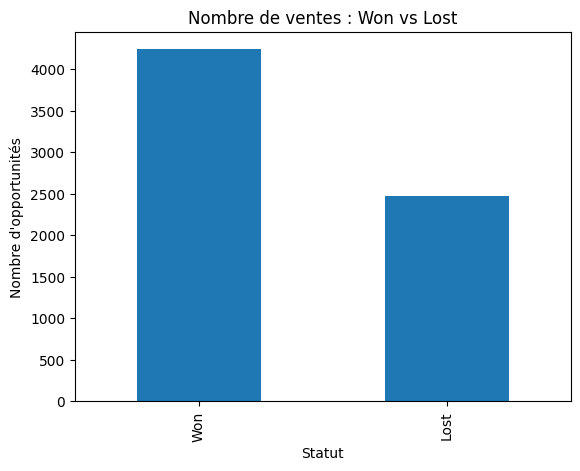

In [ ]:
df_sales_pipeline['deal_stage'] \
    .value_counts() \
    .loc[['Won', 'Lost']] \
    .plot(kind='bar')

plt.title("Nombre de ventes : Won vs Lost")
plt.ylabel("Nombre d'opportunités")
plt.xlabel("Statut")
plt.show()


Les ventes réussies et non réussies présentent des cycles de vente très similaires en durée. L’issue d’une opportunité ne semble donc pas dépendre du temps d’engagement, mais plutôt d’autres facteurs tels que le client, le produit, le commercial ou le montant proposé.

##Table sales_teams :

In [ ]:
# Informations sur le DataFrame "sales_teams"

df_sales_teams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   sales_agent      35 non-null     object
 1   manager          35 non-null     object
 2   regional_office  35 non-null     object
dtypes: object(3)
memory usage: 972.0+ bytes


In [ ]:
# Nombre total de doublons présents dans le DataFrame

df_sales_teams.duplicated().sum()

np.int64(0)

In [ ]:
# Vérification des NaN

df_sales_teams.isna().sum()

,0
sales_agent,0
manager,0
regional_office,0


##Table products :

Vérifions les types de données

In [ ]:
# Informations sur le DataFrame "products"

df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   product      7 non-null      object
 1   series       7 non-null      object
 2   sales_price  7 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 300.0+ bytes


Gestion des duplicates

In [ ]:
# Nombre total de doublons présent dans le dataframe

df_products.duplicated().sum()

np.int64(0)

In [ ]:
# Vérification des NaN

df_products.isna().sum()

,0
product,0
series,0
sales_price,0


In [ ]:
# Dénomination des produits commercialisés dans la table "products"

df_products['product']

,product
0,GTX Basic
1,GTX Pro
2,MG Special
3,MG Advanced
4,GTX Plus Pro
5,GTX Plus Basic
6,GTK 500


In [ ]:
# Dénomination des produits commercialisés dans la table "sales_pipeline"

df_sales_pipeline["product"].value_counts()

,count
product,
GTX Basic,1563
MG Special,1359
GTXPro,1258
MG Advanced,1181
GTX Plus Basic,1168
GTX Plus Pro,814
GTK 500,32


Je constate qu’un même produit est nommé différemment entre deux tables : "GTX Pro" dans la table sales_pipeline et "GTXPro" dans la table product. J’ai donc décidé d’harmoniser la dénomination en le renommant dans la table product.

In [ ]:
# Utilisation de la méthode .replace() pour renommer le produit dans la table "products"

df_products["product"] = df_products["product"].replace("GTX Pro", "GTXPro")
df_products["product"]

,product
0,GTX Basic
1,GTXPro
2,MG Special
3,MG Advanced
4,GTX Plus Pro
5,GTX Plus Basic
6,GTK 500


##Table accounts :

In [ ]:
# Informations sur le DataFrame "accounts"

df_accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   account           85 non-null     object 
 1   sector            85 non-null     object 
 2   year_established  85 non-null     int64  
 3   revenue           85 non-null     float64
 4   employees         85 non-null     int64  
 5   office_location   85 non-null     object 
 6   subsidiary_of     15 non-null     object 
dtypes: float64(1), int64(2), object(4)
memory usage: 4.8+ KB


Gestion des duplicates

In [ ]:
# Nombre total de doublons présent dans le dataframe

df_accounts.duplicated().sum()

np.int64(0)

In [ ]:
# Vérification des NaN

df_accounts.isna().sum()

,0
account,0
sector,0
year_established,0
revenue,0
employees,0
office_location,0
subsidiary_of,70


Je constate que 70 entreprises sur 85 ne font pas partie d’un groupe ; je remplace donc ces valeurs manquantes (NaN) par "Indépendant".

In [ ]:
# Remplacement des NaN par la valeur "Independant" grâce a la méthode .fillna()

df_accounts['subsidiary_of'] = df_accounts['subsidiary_of'].fillna('Independent')

# Analyses des données

Définition des tables créees en amont :

- df_sales_teams (tous les vendeurs)

- df_accounts (tous les clients)

- df_sales_pipeline (toutes les ventes)

- df_products (informations sur les différents produits)

- df1 (commandes abouties réussies et non réussies)

- df2 (commandes en cours de négociations et de prospections)

- df1_won (commandes abouties et réussies)

- df1_lost (commande abouties mais non réussies)

##Clients : Quels types de clients valent vraiment la peine d’être démarchés ?


### Préparation du df d'analyse

Je crée une nouvelle table main_account plus complète, regroupant pour chaque account son chiffre d’affaires, son secteur d’activité et sa taille.

In [ ]:
# Création d’un DataFrame central regroupant les informations clients (table "accounts") et les opportunités gagnées ("Won") (df1_won)

df = df1_won.merge(df_accounts, on="account" , how="left")

In [ ]:
# Je regroupe les informations numériques de nos clients : chiffre d’affaires total, chiffre d’affaires moyen et nombre de commandes réalisées

df_test = df.groupby(["account", "sector"]).agg( {"close_value": ["sum" , "mean","count"]} ).reset_index()

In [ ]:
# Je renomme les colonnes afin d’obtenir un DataFrame lisible, et non une simple matrice

df_test.columns = ['account', 'sector', 'CA', 'moyenne CA', 'nb_opps_won']

In [ ]:
# Je joins les informations générales de la table "accounts" afin d’obtenir l’ensemble des indicateurs numériques par client

main_account = df_test.merge(df_accounts, on="account" )
main_account

,account,sector_x,CA,moyenne CA,nb_opps_won,sector_y,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,101744.0,2992.470588,34,technolgy,1996,1100.04,2822,United States,Independent
1,Betasoloin,medical,97036.0,2854.000000,34,medical,1999,251.41,495,United States,Independent
2,Betatech,medical,107408.0,2026.566038,53,medical,1986,647.18,1185,Kenya,Independent
3,Bioholding,medical,90991.0,1819.820000,50,medical,2012,587.34,1356,Philipines,Independent
4,Bioplex,medical,67393.0,2173.967742,31,medical,1991,326.82,1016,United States,Independent
...,...,...,...,...,...,...,...,...,...,...,...
80,Zencorporation,technolgy,86690.0,2626.969697,33,technolgy,2011,40.79,142,China,Independent
81,Zoomit,entertainment,76684.0,2323.757576,33,entertainment,1992,324.19,978,United States,Independent
82,Zotware,software,138339.0,2943.382979,47,software,1979,4478.47,13809,United States,Independent
83,Zumgoity,medical,78237.0,2173.250000,36,medical,1984,441.08,1210,United States,Independent


Création de plusieurs catégories de clients en fonction de leur taille (nombre d’employés) :
– Micro : de 0 à 9 employés
– Small : de 10 à 49 employés
– Medium : de 50 à 249 employés
– Large : 250 employés et plus »

In [ ]:
# J’ajoute une colonne "client_size" afin d’identifier la taille des entreprises selon leur nombre d’employés.

bins = [0, 10, 50, 250,float('inf')]            # Création des tranches (le float inf représente l'infini)
labels = ['Micro','Small', 'Medium', 'Large']   # Noms des tranches

main_account['client_size'] = pd.cut(main_account['employees'],
                                     bins=bins,
                                     labels=labels,
                                     right=True)

In [ ]:
main_account

,account,sector_x,CA,moyenne CA,nb_opps_won,sector_y,year_established,revenue,employees,office_location,subsidiary_of,client_size
0,Acme Corporation,technolgy,101744.0,2992.470588,34,technolgy,1996,1100.04,2822,United States,Independent,Large
1,Betasoloin,medical,97036.0,2854.000000,34,medical,1999,251.41,495,United States,Independent,Large
2,Betatech,medical,107408.0,2026.566038,53,medical,1986,647.18,1185,Kenya,Independent,Large
3,Bioholding,medical,90991.0,1819.820000,50,medical,2012,587.34,1356,Philipines,Independent,Large
4,Bioplex,medical,67393.0,2173.967742,31,medical,1991,326.82,1016,United States,Independent,Large
...,...,...,...,...,...,...,...,...,...,...,...,...
80,Zencorporation,technolgy,86690.0,2626.969697,33,technolgy,2011,40.79,142,China,Independent,Medium
81,Zoomit,entertainment,76684.0,2323.757576,33,entertainment,1992,324.19,978,United States,Independent,Large
82,Zotware,software,138339.0,2943.382979,47,software,1979,4478.47,13809,United States,Independent,Large
83,Zumgoity,medical,78237.0,2173.250000,36,medical,1984,441.08,1210,United States,Independent,Large


In [ ]:
# Je supprime la colonne "sector_y", dupliquée suite au .merge(), puis je renomme "sector_x" en "sector".

main_account = main_account.drop('sector_y', axis=1,)
main_account = main_account.rename(columns={'sector_x': 'sector'})

In [ ]:
# Vérification des modifications

main_account

,account,sector,CA,moyenne CA,nb_opps_won,year_established,revenue,employees,office_location,subsidiary_of,client_size
0,Acme Corporation,technolgy,101744.0,2992.470588,34,1996,1100.04,2822,United States,Independent,Large
1,Betasoloin,medical,97036.0,2854.000000,34,1999,251.41,495,United States,Independent,Large
2,Betatech,medical,107408.0,2026.566038,53,1986,647.18,1185,Kenya,Independent,Large
3,Bioholding,medical,90991.0,1819.820000,50,2012,587.34,1356,Philipines,Independent,Large
4,Bioplex,medical,67393.0,2173.967742,31,1991,326.82,1016,United States,Independent,Large
...,...,...,...,...,...,...,...,...,...,...,...
80,Zencorporation,technolgy,86690.0,2626.969697,33,2011,40.79,142,China,Independent,Medium
81,Zoomit,entertainment,76684.0,2323.757576,33,1992,324.19,978,United States,Independent,Large
82,Zotware,software,138339.0,2943.382979,47,1979,4478.47,13809,United States,Independent,Large
83,Zumgoity,medical,78237.0,2173.250000,36,1984,441.08,1210,United States,Independent,Large


In [ ]:
# Statistiques descriptives du Dataframe général "account"

main_account.describe()

,CA,moyenne CA,nb_opps_won,year_established,revenue,employees
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,117712.164706,2386.531741,49.858824,1996.105882,1994.632941,4660.823529
std,46525.656119,460.996579,18.538347,8.865427,2169.491436,5715.601198
min,51632.000000,1564.606061,23.000000,1979.000000,4.540000,9.000000
25%,85047.000000,2052.200000,36.000000,1989.000000,497.110000,1179.000000
50%,111533.000000,2323.757576,47.000000,1996.000000,1223.720000,2769.000000
75%,140086.000000,2703.272727,57.000000,2002.000000,2741.370000,5595.000000
max,341455.000000,3528.270833,115.000000,2017.000000,11698.030000,34288.000000


A partir de main_account, je vais réaliser l'analyse "client"
  




### Par secteur d'activité

In [ ]:
# CA par secteur

secteur = main_account.groupby('sector')['CA'].sum().reset_index()
secteur = secteur.sort_values(by = 'CA', ascending = False)
secteur

,sector,CA
5,retail,1867528.0
8,technolgy,1515487.0
4,medical,1359595.0
7,software,1077934.0
2,finance,950908.0
3,marketing,922321.0
1,entertainment,689007.0
9,telecommunications,653574.0
6,services,533006.0
0,employment,436174.0


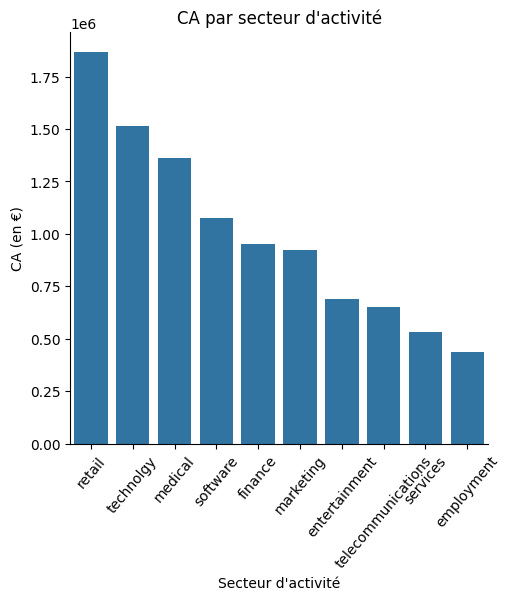

In [ ]:
sns.catplot(secteur,
            kind='bar',
            x= 'sector', y= 'CA')


plt.title("CA par secteur d'activité")
plt.xlabel("Secteur d'activité")
plt.ylabel("CA (en €)")


plt.xticks(rotation = 50)


plt.show()

### Par taille

In [ ]:
# Création d'un dataframe "taille" qui regroupe le CA en fonction de la taille des clients

taille = main_account.groupby('client_size')['CA'].sum().reset_index()
taille.sort_values(by='CA', inplace = True , ascending = False)
taille

/tmp/ipython-input-631/4160191396.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taille = main_account.groupby('client_size')['CA'].sum().reset_index()


,client_size,CA
3,Large,9359843.0
2,Medium,439281.0
0,Micro,206410.0
1,Small,0.0


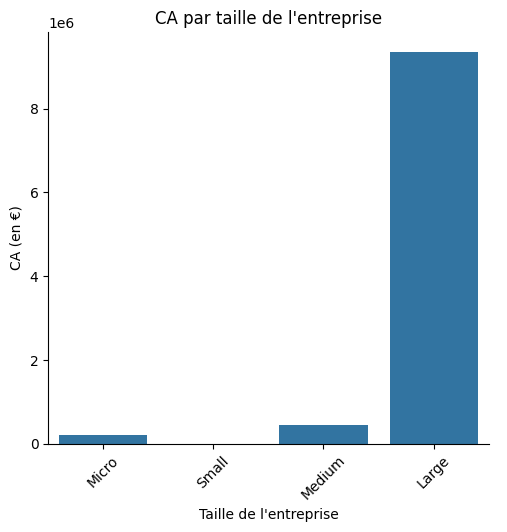

In [ ]:
sns.catplot(taille,
            kind='bar',
            x= 'client_size', y= 'CA')



plt.title("CA par taille de l'entreprise")
plt.xlabel("Taille de l'entreprise")
plt.ylabel("CA (en €)")


plt.xticks(rotation = 45)


plt.show()

In [ ]:
# Création d'un Dataframe "taille_mean" qui regroupe le CA moyen en fonction de la taille des clients

taille_mean = main_account.groupby('client_size')['CA'].mean().reset_index()
taille_mean.sort_values(by='CA', inplace = True , ascending = False)
taille_mean

/tmp/ipython-input-631/2931468105.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taille_mean = main_account.groupby('client_size')['CA'].mean().reset_index()


,client_size,CA
0,Micro,206410.000000
3,Large,119997.987179
2,Medium,73213.500000
1,Small,NaN


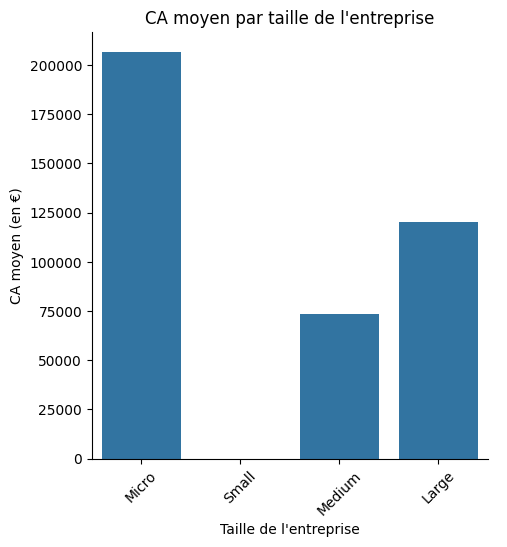

In [ ]:
sns.catplot(taille_mean,
            kind='bar',
            x= 'client_size', y= 'CA')



plt.title("CA moyen par taille de l'entreprise")
plt.xlabel("Taille de l'entreprise")
plt.ylabel("CA moyen (en €)")


plt.xticks(rotation = 45)


plt.show()

In [ ]:
# Corrélation entre le nombre d'employé et le CA d'un client

main_account["employees"].corr(main_account["CA"])

np.float64(0.6825818817476533)

J’observe une corrélation positive (0,68) entre le nombre d’employés et le chiffre d’affaires : plus une entreprise est grande en termes d’effectif, plus elle génère de chiffre d’affaires.

### Par région

In [ ]:
# Création d'un Dataframe "location" qui regroupe les entreprises par leur localisation en fonction du CA

location = main_account.groupby('office_location')['CA'].sum().reset_index().sort_values(by = "CA", ascending = False)
location

,office_location,CA
14,United States,8426955.0
8,Korea,194957.0
6,Jordan,163339.0
10,Panama,151777.0
5,Japan,123506.0
0,Belgium,117463.0
9,Norway,115712.0
4,Italy,114352.0
7,Kenya,107408.0
12,Poland,106754.0


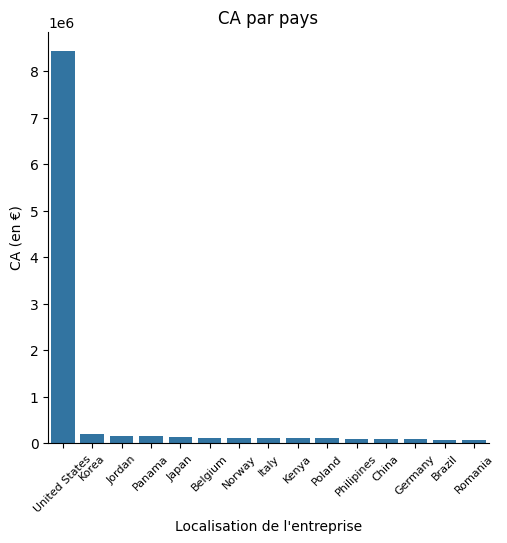

In [ ]:
# Création d'un graphique

sns.catplot(location,
            kind='bar',
            x= 'office_location', y= 'CA')



plt.title("CA par pays")
plt.xlabel("Localisation de l'entreprise")
plt.ylabel("CA (en €)")


plt.xticks(rotation = 45)
plt.xticks(fontsize = 8)


plt.show()

In [ ]:
# Création d’un DataFrame "location_mean" regroupant les entreprises par localisation en fonction du chiffre d’affaires moyen

location_mean = main_account.groupby('office_location')['CA'].mean().reset_index()
location_mean.sort_values(by = 'CA', inplace = True , ascending = False)
location_mean

,office_location,CA
8,Korea,194957.000000
6,Jordan,163339.000000
10,Panama,151777.000000
5,Japan,123506.000000
14,United States,118689.507042
0,Belgium,117463.000000
9,Norway,115712.000000
4,Italy,114352.000000
7,Kenya,107408.000000
12,Poland,106754.000000


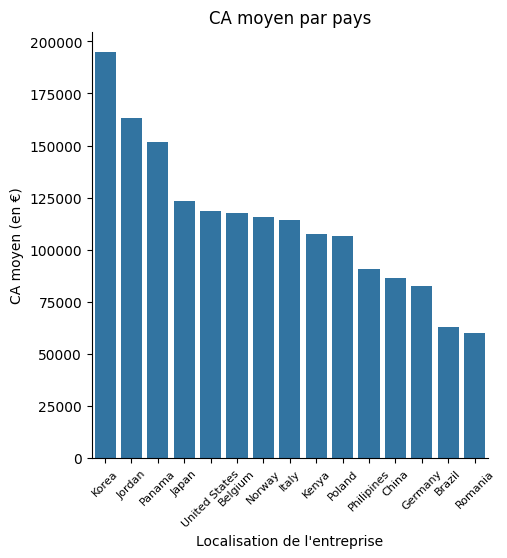

In [ ]:
sns.catplot(location_mean,
            kind='bar',
            x= 'office_location', y= 'CA')


plt.title("CA moyen par pays")
plt.xlabel("Localisation de l'entreprise")
plt.ylabel("CA moyen (en €)")

plt.xticks(rotation = 45)
plt.xticks(fontsize = 8)


plt.show()

###Taux de conversion par type d’opportunité

In [ ]:
# Comptage du nombre total d’opportunités par client, tous statuts confondus (Won, Lost, Engaging, Prospecting)

df_test2 = df_sales_pipeline.groupby('account')['opportunity_id'].count().reset_index()

In [ ]:
# # Création d’une colonne "conversion_rate" calculant le taux de conversion pour chaque client, puis classement afin d’identifier les meilleurs clients

main_account['conversion_rate'] = main_account['nb_opps_won']/df_test2['opportunity_id']
main_account[['account', 'conversion_rate']].sort_values(by='conversion_rate', ascending = False)

,account,conversion_rate
55,Rangreen,0.688073
30,Goodsilron,0.684211
25,Gekko & Co,0.681818
49,Newex,0.672727
74,Warephase,0.660377
...,...,...
76,Xx-zobam,0.489362
61,Silis,0.486111
65,Statholdings,0.478873
6,Bluth Company,0.474576


##Produits : quels sont les produits générant le plus de chiffre d’affaires ? Lesquels sont les plus vendus et auprès de quels clients ?


### Préparation du df d'analyse

Je crée une nouvelle table products plus complète, avec une ligne par produit, intégrant pour chacun le chiffre d’affaires total, le chiffre d’affaires moyen, le nombre d’opportunités gagnées et d’autres indicateurs clés.

In [ ]:
# Jointure de deux DataFrames : df1_won, regroupant toutes les opportunités réalisées, et df_products, contenant les informations produits.

df = df1_won.merge(df_products, on="product" , how="left") ## merge opp wons + product

In [ ]:
# Calculs du CA, CA moyen et nombre de vente par produit

df_test4 = df.groupby(["product"]).agg( {"close_value": ["sum" , "mean","count"]} ).reset_index()

In [ ]:
# Je renomme les colonnes pour ne plus avoir de matrice

df_test4.columns = ['product', 'CA', 'CA moyen', 'nb_opps_won']
df_test4

,product,CA,CA moyen,nb_opps_won
0,GTK 500,400612.0,26707.466667,15
1,GTX Basic,499263.0,545.642623,915
2,GTX Plus Basic,705275.0,1080.053599,653
3,GTX Plus Pro,2629651.0,5489.876827,479
4,GTXPro,3510578.0,4815.607682,729
5,MG Advanced,2216387.0,3388.970948,654
6,MG Special,43768.0,55.192938,793


In [ ]:
# Création du DataFrame "product_main" qui regroupe les infos par produits calculées précedement

product_main = df_test4.merge(df_products, on="product" )
product_main

,product,CA,CA moyen,nb_opps_won,series,sales_price
0,GTK 500,400612.0,26707.466667,15,GTK,26768
1,GTX Basic,499263.0,545.642623,915,GTX,550
2,GTX Plus Basic,705275.0,1080.053599,653,GTX,1096
3,GTX Plus Pro,2629651.0,5489.876827,479,GTX,5482
4,GTXPro,3510578.0,4815.607682,729,GTX,4821
5,MG Advanced,2216387.0,3388.970948,654,MG,3393
6,MG Special,43768.0,55.192938,793,MG,55


### CA généré par produit

In [ ]:
# Classement des produits en fonction de leur chiffre d’affaires

product_main.sort_values(by='CA', inplace = True, ascending = False)

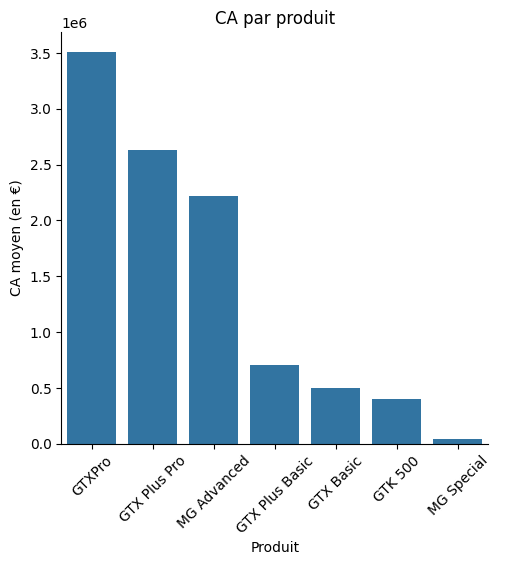

In [ ]:
sns.catplot(product_main,
            kind='bar',
            x= 'product', y= 'CA')


plt.title("CA par produit")
plt.xlabel("Produit")
plt.ylabel("CA moyen (en €)")


plt.xticks(rotation = 45)


plt.show()

### CA moyen par produit

In [ ]:
# Classement des produits en fonction de leur CA moyen

product_main.sort_values(by='CA moyen', inplace = True, ascending = False)

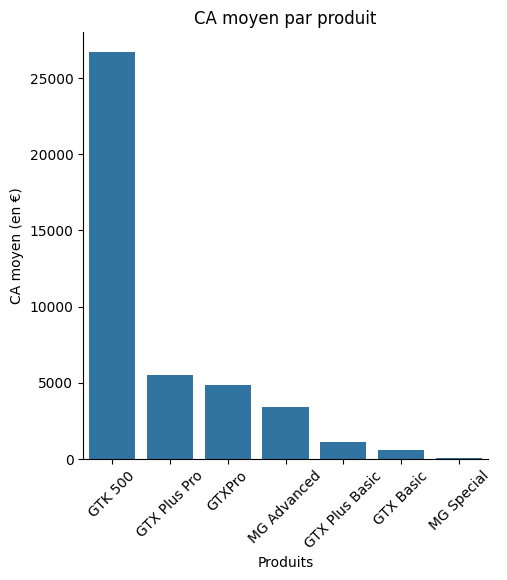

In [ ]:
sns.catplot(product_main,
            kind='bar',
            x= 'product', y= 'CA moyen')


plt.title("CA moyen par produit")

plt.xlabel("Produits")
plt.ylabel("CA moyen (en €)")


plt.xticks(rotation = 45)


plt.show()

### Nombre d'opportunités gagnées par produit

In [ ]:
# Classement des produits en fonction de leur nombre de ventes réussies

product_main.sort_values(by='nb_opps_won', inplace = True, ascending = False)

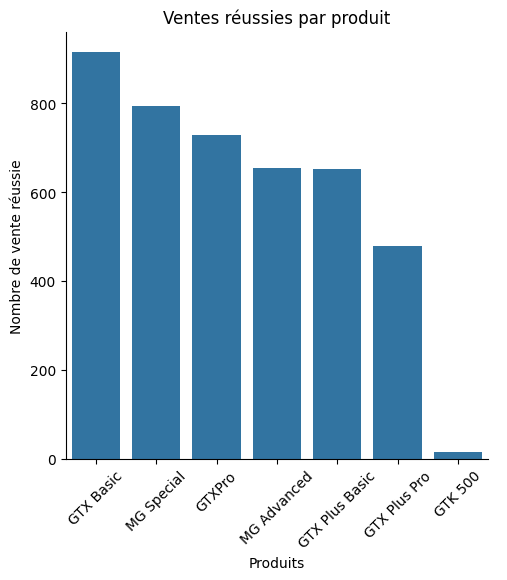

In [ ]:
sns.catplot(product_main,
            kind='bar',
            x= 'product', y= 'nb_opps_won')



plt.title("Ventes réussies par produit")
plt.xlabel("Produits")
plt.ylabel("Nombre de vente réussie")


plt.xticks(rotation = 45)


plt.show()

### Taux de conversion par produit





In [ ]:
# Nombre total d’opportunités par produit, tous statuts confondus (Won, Lost, Engaging, Prospecting)

df_test5 = df_sales_pipeline.groupby('product')['opportunity_id'].count().reset_index()
df_test5

,product,opportunity_id
0,GTK 500,32
1,GTX Basic,1563
2,GTX Plus Basic,1168
3,GTX Plus Pro,814
4,GTXPro,1258
5,MG Advanced,1181
6,MG Special,1359


In [ ]:
# Création d’une colonne "taux_conversion" calculant le taux de conversion par produit

product_main['taux_conversion'] = product_main['nb_opps_won'] / df_test5['opportunity_id']

In [ ]:
# Création d’un DataFrame df_taux regroupant les prix et le ratio de ventes réussies sur le nombre total de ventes

df_taux = product_main[['product', 'taux_conversion', 'sales_price']].sort_values(by='taux_conversion', ascending=False)
df_taux

,product,taux_conversion,sales_price
3,GTX Plus Pro,0.588452,5482
1,GTX Basic,0.585413,550
6,MG Special,0.583517,55
4,GTXPro,0.579491,4821
2,GTX Plus Basic,0.559075,1096
5,MG Advanced,0.553768,3393
0,GTK 500,0.468750,26768


Si un produit doit être mis en avant, il s’agit du GTX Pro : il présente un bon taux de conversion, ce qui indique une forte probabilité de vente, tout en affichant un prix moyen environ 100 fois supérieur à celui du MG Special.

### Analyse Produit / Clients

Un même client peut acheter plusieurs produits sur différentes opportunités, ce qui traduit une forte fidélité client et une tendance à compléter progressivement la gamme de produits proposée.

Les clients ne se limitent donc pas à un seul achat : ils reviennent pour acquérir d’autres produits, suggérant un niveau de satisfaction élevé et une relation commerciale durable.

In [ ]:
# Nombre de produits distincts achetés par chaque client

df1_won.groupby(['account', 'product']).agg({"opportunity_id": "count"})

opportunity_id
account          product                       
Acme Corporation GTX Basic                    4
                 GTX Plus Basic               7
                 GTX Plus Pro                 7
                 GTXPro                       7
                 MG Advanced                  5
...                                         ...
dambase          GTX Plus Basic               7
                 GTX Plus Pro                10
                 GTXPro                       5
                 MG Advanced                  6
                 MG Special                  16

[522 rows x 1 columns]

## Cycle de vente

###Préparation des df d'analyse

In [ ]:
# Je crée une colonne "Time_diff" dans df1_won pour calculer la durée des opportunités réussies

df1_won["Time_diff"] = df1_won["close_date"] - df1_won["engage_date"]

# Création de périodes

df1_won['mois_année'] = df1_won["close_date"].dt.to_period('M')    # Par mois
df1_won['quarter_année'] = df1_won["close_date"].dt.to_period('Q') # Par trimestre

df1_won[["mois_année",'quarter_année']]

/tmp/ipython-input-631/606869150.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_won["Time_diff"] = df1_won["close_date"] - df1_won["engage_date"]
/tmp/ipython-input-631/606869150.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_won['mois_année'] = df1_won["close_date"].dt.to_period('M')    # Par mois
/tmp/ipython-input-631/606869150.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

,mois_année,quarter_année
0,2017-03,2017Q1
1,2017-03,2017Q1
2,2017-03,2017Q1
3,2017-03,2017Q1
4,2017-03,2017Q1
...,...,...
8295,2017-12,2017Q4
8296,2017-12,2017Q4
8297,2017-12,2017Q4
8298,2017-12,2017Q4


In [ ]:
# J’applique la même procédure aux opportunités non réussies

df1_lost["Time_diff"] = df1_lost["close_date"] - df1_lost["engage_date"]

# Création de périodes

df1_lost['mois_année'] = df1_lost["close_date"].dt.to_period('M')
df1_lost['quarter_année'] = df1_lost["close_date"].dt.to_period('Q')

df1_lost[["mois_année", 'quarter_année']]

/tmp/ipython-input-631/978063954.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_lost["Time_diff"] = df1_lost["close_date"] - df1_lost["engage_date"]
/tmp/ipython-input-631/978063954.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_lost['mois_année'] = df1_lost["close_date"].dt.to_period('M')
/tmp/ipython-input-631/978063954.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

,mois_année,quarter_année
11,2017-03,2017Q1
15,2017-03,2017Q1
18,2017-03,2017Q1
20,2017-03,2017Q1
27,2017-03,2017Q1
...,...,...
8263,2017-12,2017Q4
8270,2017-12,2017Q4
8278,2017-12,2017Q4
8282,2017-12,2017Q4


In [ ]:
# Même procedure sur notre df1, les opps "won" & "lost" seulement

df1["Time_diff"] = df1["close_date"] - df1["engage_date"]
df1['mois_année'] = df1["close_date"].dt.to_period('M')
df1['quarter_année'] = df1["close_date"].dt.to_period('Q')

/tmp/ipython-input-631/1236381944.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Time_diff"] = df1["close_date"] - df1["engage_date"]
/tmp/ipython-input-631/1236381944.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['mois_année'] = df1["close_date"].dt.to_period('M')
/tmp/ipython-input-631/1236381944.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

### Calcul de la corrélation entre le nombre d’opportunités gagnées par compte et le temps moyen nécessaire pour clôturer un deal sur ce compte.

In [ ]:
# Je calcule la corrélation entre le nombre d’opportunités gagnées par client et le temps moyen de clôture des ventes.

df_time_diff = df1_won.groupby('account')['Time_diff'].mean().reset_index()
df_time_diff

,account,Time_diff
0,Acme Corporation,53 days 12:00:00
1,Betasoloin,55 days 21:52:56.470588235
2,Betatech,42 days 02:15:50.943396226
3,Bioholding,51 days 00:57:36
4,Bioplex,43 days 13:56:07.741935484
...,...,...
80,Zencorporation,46 days 18:54:32.727272727
81,Zoomit,73 days 23:16:21.818181818
82,Zotware,46 days 10:12:45.957446808
83,Zumgoity,50 days 02:00:00


In [ ]:
# Jointure de la table principale des clients ayant acheté un produit avec celle des temps moyens

df_intermediaire = main_account[['account','nb_opps_won']].merge(df_time_diff, on='account')

In [ ]:
# Je calcule la corrélation entre le nombre d’opportunités gagnées par compte et le temps moyen de clôture des deals

df_intermediaire['nb_opps_won'].corr(df_intermediaire['Time_diff'])

np.float64(0.07221522159840334)

### À quelle période de l’année les opportunités sont-elles le plus souvent perdues ?


In [ ]:
# Calcul du nombre d’opportunités perdues par mois

df1_lost['mois_année'].value_counts().reset_index().sort_values("mois_année")

,mois_année,count
8,2017-03,116
4,2017-04,301
0,2017-05,367
9,2017-06,110
3,2017-07,319
2,2017-08,339
7,2017-09,132
5,2017-10,287
1,2017-11,362
6,2017-12,140


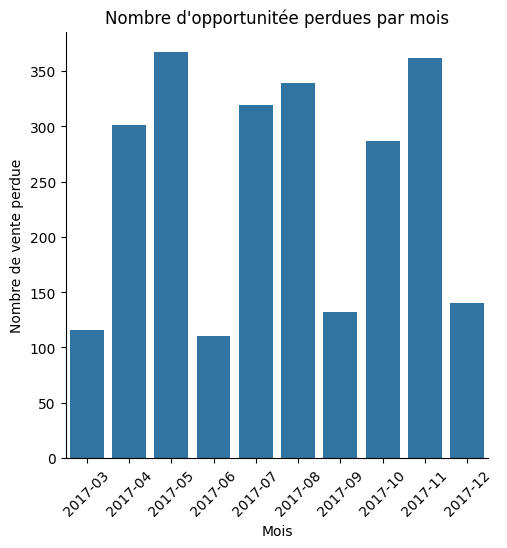

In [ ]:
sns.catplot(df1_lost['mois_année'].value_counts().reset_index().sort_values("mois_année"),
            kind='bar',
            x= 'mois_année', y= 'count',
            errorbar= None)


plt.title("Nombre d'opportunitée perdues par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de vente perdue")

plt.xticks(rotation = 45)


plt.show()

### À quel moment de l’année gagnons-nous des deals ?

In [ ]:
# Calcul du nombre d’opportunités gagnées par mois

df1_won['mois_année'].value_counts().reset_index().sort_values("mois_année")

,mois_année,count
0,2017-03,531
8,2017-04,285
5,2017-05,438
1,2017-06,531
7,2017-07,308
4,2017-08,446
3,2017-09,503
9,2017-10,279
6,2017-11,406
2,2017-12,511


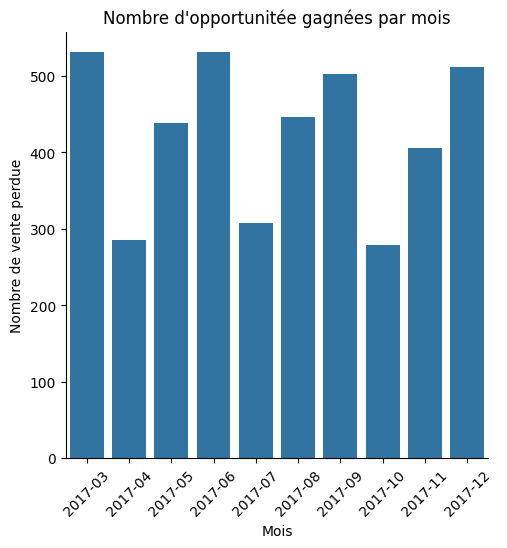

In [ ]:
sns.catplot(df1_won['mois_année'].value_counts().reset_index().sort_values("mois_année"),
            kind='bar',
            x= 'mois_année', y= 'count',
            errorbar= None)


plt.title("Nombre d'opportunitée gagnées par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de vente perdue")


plt.xticks(rotation = 45)


plt.show()

Regroupement des deux graphiques sur un seul graphique afin de faciliter la comparaison.





In [ ]:
# Calcul du nombre d’opportunités gagnées ("Won") et perdues ("Lost") par mois

df1[["deal_stage", "mois_année"]].groupby("deal_stage").value_counts().reset_index().sort_values("mois_année")

,deal_stage,mois_année,count
10,Won,2017-03,531
8,Lost,2017-03,116
4,Lost,2017-04,301
18,Won,2017-04,285
15,Won,2017-05,438
0,Lost,2017-05,367
11,Won,2017-06,531
9,Lost,2017-06,110
17,Won,2017-07,308
3,Lost,2017-07,319


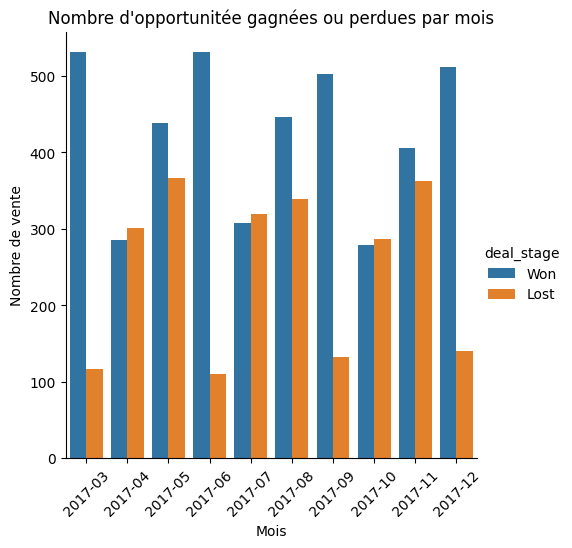

In [ ]:
sns.catplot(df1[["deal_stage", "mois_année"]].groupby("deal_stage").value_counts().reset_index().sort_values("mois_année"),
            kind='bar',
            x= 'mois_année', y= 'count',
            hue= "deal_stage")


plt.title("Nombre d'opportunitée gagnées ou perdues par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de vente")


plt.xticks(rotation = 45)


plt.show()

###Quel est le délai moyen nécessaire pour conclure une vente ?

In [ ]:
# Durée moyenne nécessaire pour conclure une vente réussie

df1_won['Time_diff'].mean()

Timedelta('51 days 18:46:02.435110901')

In [ ]:
# Durée moyenne nécessaire pour conclure une vente perdue

df1_lost['Time_diff'].mean()

Timedelta('41 days 11:30:00.727860897')

## Performance des équipes commerciales

###Quels commerciaux ou quels bureaux régionaux concluent les deals les plus importants ?


In [ ]:
# Jointure afin d’obtenir les vendeurs ainsi que la localisation de leur point de vente

df_won_teams = df1_won.merge(df_sales_teams[['sales_agent','regional_office']], how='left', on='sales_agent')
df_won_teams

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,Time_diff,mois_année,quarter_année,regional_office
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,132 days,2017-03,2017Q1,Central
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,137 days,2017-03,2017Q1,Central
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,133 days,2017-03,2017Q1,Central
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,135 days,2017-03,2017Q1,Central
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,128 days,2017-03,2017Q1,West
...,...,...,...,...,...,...,...,...,...,...,...,...
4233,2EBLR9N8,Lajuana Vencill,GTX Basic,Conecom,Won,2017-12-24,2017-12-26,622.0,2 days,2017-12,2017Q4,Central
4234,VDGA4KXA,Violet Mclelland,GTX Plus Basic,Bluth Company,Won,2017-12-24,2017-12-30,1093.0,6 days,2017-12,2017Q4,East
4235,6WCNNK5J,Maureen Marcano,GTXPro,Hottechi,Won,2017-12-26,2017-12-29,4433.0,3 days,2017-12,2017Q4,West
4236,YJTQSZ9D,Gladys Colclough,GTX Plus Basic,Inity,Won,2017-12-27,2017-12-30,1052.0,3 days,2017-12,2017Q4,Central


In [ ]:
# Création d’un DataFrame "top_vendeurs" regroupant le chiffre d’affaires, le nombre d’opportunités réussies et le CA moyen par opportunité

df_top_agent = (df_won_teams.groupby(['sales_agent', 'regional_office'])['close_value'].agg(total_won_value='sum',won_deals_count='count',
avg_won_value='mean').sort_values('total_won_value', ascending = False).reset_index()
)

df_top_agent.head()

,sales_agent,regional_office,total_won_value,won_deals_count,avg_won_value
0,Darcel Schlecht,Central,1153214.0,349,3304.338109
1,Vicki Laflamme,West,478396.0,221,2164.687783
2,Kary Hendrixson,West,454298.0,209,2173.674641
3,Cassey Cress,East,450489.0,163,2763.736196
4,Donn Cantrell,East,445860.0,158,2821.898734


In [ ]:
# Création d’un DataFrame similaire pour les points de vente

df_top_office = (df_won_teams.groupby('regional_office')['close_value'].agg(total_won_value='sum', won_deals_count='count',
avg_won_value='mean').sort_values('total_won_value', ascending=False).reset_index())

df_top_office

,regional_office,total_won_value,won_deals_count,avg_won_value
0,West,3568647.0,1438,2481.673853
1,Central,3346293.0,1629,2054.200737
2,East,3090594.0,1171,2639.277541


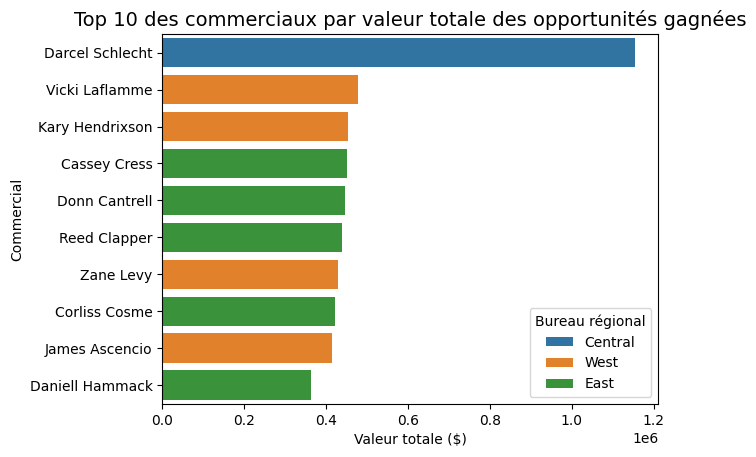

In [ ]:
# Création d’un top 10 de tous les vendeurs

df_top10 = df_top_agent.head(10)


sns.barplot(data=df_top10,
            x='total_won_value', y='sales_agent',
            hue='regional_office')


plt.title("Top 10 des commerciaux par valeur totale des opportunités gagnées", fontsize=14)
plt.xlabel("Valeur totale ($)")
plt.ylabel("Commercial")
plt.legend(title="Bureau régional")


plt.show()

In [ ]:
# Somme des ventes par produit pour chaque agent

df_by_agent_product = df1_won.groupby(['sales_agent','product'])['close_value'].sum().reset_index(name='total_won_value')
df_by_agent_product = df_by_agent_product.sort_values(['sales_agent','total_won_value'], ascending=[True, False])

df_by_agent_product

,sales_agent,product,total_won_value
2,Anna Snelling,GTX Plus Pro,152674.0
3,Anna Snelling,MG Advanced,72008.0
1,Anna Snelling,GTX Plus Basic,27241.0
0,Anna Snelling,GTX Basic,17437.0
4,Anna Snelling,MG Special,5696.0
...,...,...,...
172,Zane Levy,GTX Plus Pro,115301.0
174,Zane Levy,MG Advanced,34996.0
171,Zane Levy,GTX Plus Basic,28125.0
170,Zane Levy,GTX Basic,26068.0


###Y a-t-il des équipes sous-performantes par rapport aux autres ?

In [ ]:
# Création de deux DataFrames : l’un contenant uniquement les opportunités "Won" et l’autre les opportunités "Lost", avec les informations des vendeurs

won_sales_teams = df1_won.merge(df_sales_teams, on='sales_agent' , how='left')
lost_sales_teams = df1_lost.merge(df_sales_teams, on='sales_agent' , how='left')

In [ ]:
# Nombre d’opportunités gagnées ("Won") par point de vente

nbwon_region = won_sales_teams.groupby('regional_office').agg({"deal_stage" : "count"}).reset_index()
nbwon_region = nbwon_region.rename(columns  ={'deal_stage' : 'nb_opps_won'})
nbwon_region

,regional_office,nb_opps_won
0,Central,1629
1,East,1171
2,West,1438


In [ ]:
# Nombre d’opportunités perdues ("Lost") par point de vente

nblost_region = lost_sales_teams.groupby('regional_office').agg({"deal_stage" : "count"}).reset_index()
nblost_region = nblost_region.rename(columns={'deal_stage': 'nb_opps_lost'})
nblost_region

,regional_office,nb_opps_lost
0,Central,975
1,East,687
2,West,811


In [ ]:
# Fusion des DataFrames pour obtenir une vue générale

nb_region = nblost_region.merge(nbwon_region, on='regional_office')
nb_region

,regional_office,nb_opps_lost,nb_opps_won
0,Central,975,1629
1,East,687,1171
2,West,811,1438


In [ ]:
# Ratio du nombre de ventes réussies sur le nombre total de ventes

nb_region['taux_reussite'] = nb_region['nb_opps_won'] / (nb_region['nb_opps_lost'] + nb_region['nb_opps_won'])

# Ratio du nombre de ventes perdues sur le nombre total de ventes

nb_region['taux_echec'] = nb_region['nb_opps_lost'] / (nb_region['nb_opps_lost'] + nb_region['nb_opps_won'])

nb_region

,regional_office,nb_opps_lost,nb_opps_won,taux_reussite,taux_echec
0,Central,975,1629,0.625576,0.374424
1,East,687,1171,0.630248,0.369752
2,West,811,1438,0.639395,0.360605


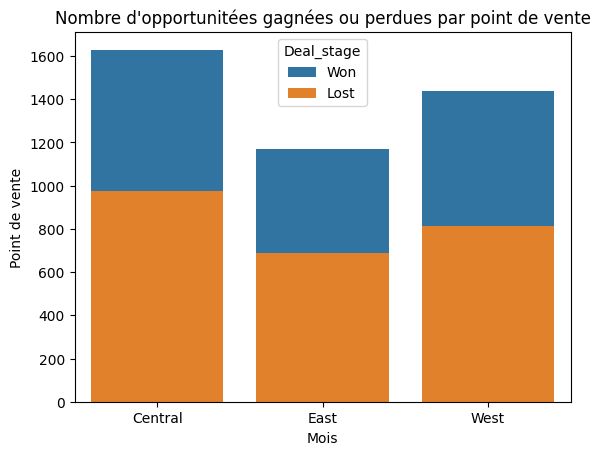

In [ ]:
# Création d'un graphique

# 1er histogramme "Won"
sns.barplot(nb_region,
            x= 'regional_office', y= 'nb_opps_won', label="Won")

# 2eme histogramme "Lost"
sns.barplot(nb_region,
            x= 'regional_office', y= 'nb_opps_lost',  label="Lost")


plt.title("Nombre d'opportunitées gagnées ou perdues par point de vente")
plt.xlabel("Mois")
plt.ylabel("Point de vente")
plt.legend(title="Deal_stage")

plt.show()

Conclusion : Les bureaux régionaux affichent des niveaux de performance relativement homogènes.

In [ ]:
# Nombre d’opportunités gagnées ("Won") par agent

nbwon_agent = won_sales_teams.groupby('sales_agent').agg({"deal_stage" : "count"}).reset_index()
nbwon_agent = nbwon_agent.rename(columns={'deal_stage': 'nb_opps_won'})
nbwon_agent

,sales_agent,nb_opps_won
0,Anna Snelling,208
1,Boris Faz,101
2,Cassey Cress,163
3,Cecily Lampkin,107
4,Corliss Cosme,150
5,Daniell Hammack,114
6,Darcel Schlecht,349
7,Donn Cantrell,158
8,Elease Gluck,80
9,Garret Kinder,75


In [ ]:
# Nombre d’opportunités perdues ("Lost") par agent

nblost_agent = lost_sales_teams.groupby('sales_agent').agg({"deal_stage" : "count"}).reset_index()
nblost_agent = nblost_agent.rename(columns={'deal_stage': 'nb_opps_lost'})
nblost_agent

,sales_agent,nb_opps_lost
0,Anna Snelling,128
1,Boris Faz,52
2,Cassey Cress,98
3,Cecily Lampkin,53
4,Corliss Cosme,79
5,Daniell Hammack,73
6,Darcel Schlecht,204
7,Donn Cantrell,117
8,Elease Gluck,46
9,Garret Kinder,48


In [ ]:
# Fusion des DataFrames pour obtenir une vue générale

nb_agent = nbwon_agent.merge(nblost_agent, on='sales_agent')
nb_agent

,sales_agent,nb_opps_won,nb_opps_lost
0,Anna Snelling,208,128
1,Boris Faz,101,52
2,Cassey Cress,163,98
3,Cecily Lampkin,107,53
4,Corliss Cosme,150,79
5,Daniell Hammack,114,73
6,Darcel Schlecht,349,204
7,Donn Cantrell,158,117
8,Elease Gluck,80,46
9,Garret Kinder,75,48


In [ ]:
# Ratio du nombre de ventes réussies et perdues sur le nombre total de ventes

nb_agent['taux_reussite'] = nb_agent['nb_opps_won']/(nb_agent['nb_opps_lost']+nb_agent['nb_opps_won'])
nb_agent['taux_echec'] = 1 - nb_agent['taux_reussite']
nb_agent = nb_agent.sort_values(by='taux_reussite' , ascending = False )
nb_agent

,sales_agent,nb_opps_won,nb_opps_lost,taux_reussite,taux_echec
11,Hayden Neloms,107,45,0.703947,0.296053
19,Maureen Marcano,149,64,0.699531,0.300469
28,Wilburn Farren,55,24,0.696203,0.303797
3,Cecily Lampkin,107,53,0.668750,0.331250
25,Versie Hillebrand,176,88,0.666667,0.333333
20,Moses Frase,129,66,0.661538,0.338462
1,Boris Faz,101,52,0.660131,0.339869
12,James Ascencio,135,71,0.655340,0.344660
4,Corliss Cosme,150,79,0.655022,0.344978
23,Rosalina Dieter,72,38,0.654545,0.345455


En termes de ratio ventes perdues / ventes gagnées, Hayden Neloms apparaît comme le top performer. Toutefois, lorsque l’on rapporte cette performance au nombre total de deals traités, certains agents se révèlent plus efficients, car ils génèrent un volume bien plus important d’opportunités. Par exemple, Darcel Schlecht a traité 553 deals au total tout en maintenant un taux de conversion solide de 63 %.

Corrélation : les commerciaux qui concluent le plus de deals génèrent-ils davantage de chiffre d’affaires ?

In [ ]:
# Corrélation entre le nombre de deals gagnés ("Won") et le chiffre d’affaires total

df_top_agent[['won_deals_count','total_won_value']].corr()

,won_deals_count,total_won_value
won_deals_count,1.000000,0.811366
total_won_value,0.811366,1.000000



J'observe une corrélation forte et positive entre le nombre de deals gagnés et le chiffre d’affaires total par commercial. Les commerciaux qui concluent un plus grand nombre d’opportunités génèrent ainsi globalement davantage de revenus.